# 02. Statistical Time Series Models

このノートブックでは、`UCI Individual Household Electric Power Consumption` データの `Global_active_power` を対象に、統計的な時系列予測モデルを実装する。

扱う内容は、指定された順に以下の通り。

0. 訓練データとテストデータに分割
1. ベースモデルの実装
2. ベースモデルの予測精度の指標を実装
3. ベースモデルを可視化し、結果をDataFrameでまとめる
4. ベースモデルを一つの図にまとめて表示
5. 単変量時系列モデルの実装
6. 単変量モデルの予測精度をDataFrameでまとめる
7. 単変量時系列モデルの可視化


## 分析の準備

既存ノートブックと同じく、ベースラインには `sktime` の `NaiveForecaster`、単変量時系列モデルには `statsmodels` の指数平滑化モデルを用いる。


In [1]:
# 数値計算・データ処理
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt

# パス操作
from pathlib import Path

# 評価指標
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ベースラインモデル
from sktime.forecasting.naive import NaiveForecaster

# 単変量時系列モデル
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 警告の抑制
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


## データの読み込み

`01_preprocessing_eda.ipynb` で作成した前処理済みデータがある場合はそれを使い、存在しない場合は元データから日次平均系列を作成する。


In [2]:
processed_candidates = [
    Path("data/processed/global_active_power_daily.csv"),
    Path("global_active_power_daily.csv"),
    Path("/mnt/data/data/processed/global_active_power_daily.csv"),
    Path("/mnt/data/global_active_power_daily.csv"),
]

raw_candidates = [
    Path("../data/household_power_consumption.txt"),
    Path("household_power_consumption.txt"),
    Path("/mnt/data/household_power_consumption.txt"),
]

y_daily = None

for path in processed_candidates:
    if path.exists():
        print(f"前処理済み日次データを読み込みます: {path}")
        tmp = pd.read_csv(path, index_col=0, parse_dates=True)
        if "Global_active_power" in tmp.columns:
            y_daily = tmp[["Global_active_power"]].copy()
        else:
            y_daily = tmp.iloc[:, [0]].copy()
            y_daily.columns = ["Global_active_power"]
        break

if y_daily is None:
    for path in raw_candidates:
        if path.exists():
            print(f"元データを読み込み、日次平均系列を作成します: {path}")
            df_raw = pd.read_csv(
                path,
                sep=";",
                na_values=["?", "NA", "NaN", ""],
                low_memory=False,
            )
            df_raw["datetime"] = pd.to_datetime(
                df_raw["Date"] + " " + df_raw["Time"],
                format="%d/%m/%Y %H:%M:%S",
                errors="coerce",
            )
            df = df_raw.drop(columns=["Date", "Time"]).set_index("datetime")
            df = df[~df.index.isna()].sort_index()
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
            df = df[~df.index.duplicated(keep="first")]
            df = df.asfreq("1min")
            df = df.interpolate(method="time").ffill().bfill()
            y_daily = df[["Global_active_power"]].resample("D").mean()
            break

if y_daily is None:
    raise FileNotFoundError("前処理済みデータまたは元データが見つかりません。")

y_daily = y_daily.dropna().sort_index().asfreq("D")
y_daily["Global_active_power"] = y_daily["Global_active_power"].interpolate(method="time").ffill().bfill()

print("データ期間:", y_daily.index.min(), "〜", y_daily.index.max())
print("データ数:", len(y_daily))
display(y_daily.head())
display(y_daily.tail())


元データを読み込み、日次平均系列を作成します: ..\data\household_power_consumption.txt
データ期間: 2006-12-16 00:00:00 〜 2010-11-26 00:00:00
データ数: 1442


,Global_active_power
datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


,Global_active_power
datetime,
2010-11-22,1.417733
2010-11-23,1.095511
2010-11-24,1.247394
2010-11-25,0.993864
2010-11-26,1.178230


## 0. 訓練データとテストデータに分割

時系列データでは、未来の情報を学習時に使わないようにする必要がある。  
そのため、ランダム分割ではなく、時系列順に前半80%を訓練データ、後半20%をテストデータとする。


train期間: 2006-12-16 00:00:00 〜 2010-02-10 00:00:00
test期間 : 2010-02-11 00:00:00 〜 2010-11-26 00:00:00
train size: 1153
test size : 289


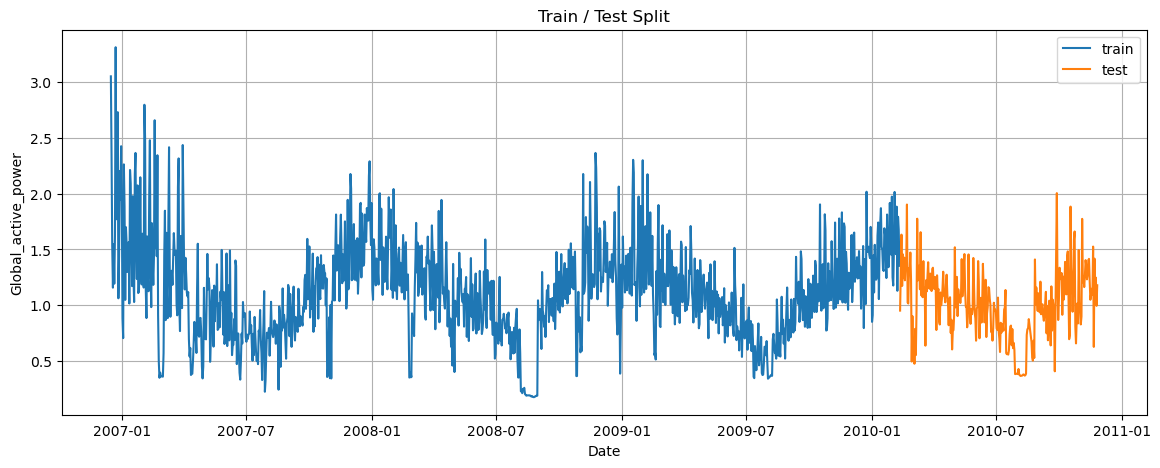

In [3]:
series = y_daily["Global_active_power"].copy()
series = series.dropna().sort_index().asfreq("D")
series = series.interpolate(method="time").ffill().bfill()

train_size = int(len(series) * 0.8)
y_train = series.iloc[:train_size]
y_test = series.iloc[train_size:]

print("train期間:", y_train.index.min(), "〜", y_train.index.max())
print("test期間 :", y_test.index.min(), "〜", y_test.index.max())
print("train size:", len(y_train))
print("test size :", len(y_test))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index, y_train, label="train")
ax.plot(y_test.index, y_test, label="test")
ax.set_title("Train / Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.grid(True)
ax.legend()
plt.show()


## 1. ベースモデルの実装

本格的な予測モデルを作成する前に、比較基準となる単純な予測モデルを作成する。

ここでは以下の5つをベースラインとして用いる。

1. 平均値予測
2. Naive予測
3. 季節Naive予測
4. 移動平均予測
5. ドリフト予測

家庭電力データでは、時刻・曜日・季節による周期性が確認されるため、単純な平均値予測だけでなく、直近値や季節周期を利用する予測も重要な比較基準になる。


In [4]:
fh = np.arange(1, len(y_test) + 1)

# 日次データなので、週周期を想定する。
# 年周期を使いたい場合は 365 に変更する。
seasonal_period = 7

# 移動平均の窓幅。日次データの直近水準を見るため30日とする。
moving_average_window = 30


### 平均値予測


In [5]:
mean_forecaster = NaiveForecaster(strategy="mean")
mean_forecaster.fit(y_train)
mean_pred = mean_forecaster.predict(fh)
mean_pred.name = "mean"


### Naive予測


In [6]:
naive_forecaster = NaiveForecaster(strategy="last")
naive_forecaster.fit(y_train)
naive_pred = naive_forecaster.predict(fh)
naive_pred.name = "naive"


### 季節Naive予測


In [7]:
seasonal_naive_forecaster = NaiveForecaster(strategy="last", sp=seasonal_period)
seasonal_naive_forecaster.fit(y_train)
seasonal_naive_pred = seasonal_naive_forecaster.predict(fh)
seasonal_naive_pred.name = "seasonal_naive"


### 移動平均予測


In [8]:
moving_average_forecaster = NaiveForecaster(
    strategy="mean",
    window_length=moving_average_window,
)
moving_average_forecaster.fit(y_train)
moving_average_pred = moving_average_forecaster.predict(fh)
moving_average_pred.name = "moving_average"


### ドリフト予測


In [9]:
drift_forecaster = NaiveForecaster(strategy="drift")
drift_forecaster.fit(y_train)
drift_pred = drift_forecaster.predict(fh)
drift_pred.name = "drift"


### ベースライン予測結果をDataFrameにまとめる


In [10]:
baseline_pred_df = pd.DataFrame({
    "actual": y_test,
    "mean": mean_pred,
    "naive": naive_pred,
    "seasonal_naive": seasonal_naive_pred,
    "moving_average": moving_average_pred,
    "drift": drift_pred,
})
baseline_pred_df.index = y_test.index

display(baseline_pred_df.head())
display(baseline_pred_df.tail())


,actual,mean,naive,seasonal_naive,moving_average,drift
datetime,,,,,,
2010-02-11,0.951228,1.113375,1.352794,1.608521,1.555281,1.351318
2010-02-12,1.314582,1.113375,1.352794,1.457564,1.555281,1.349842
2010-02-13,1.633025,1.113375,1.352794,1.884018,1.555281,1.348366
2010-02-14,1.172569,1.113375,1.352794,1.128964,1.555281,1.346889
2010-02-15,1.456342,1.113375,1.352794,1.793221,1.555281,1.345413


,actual,mean,naive,seasonal_naive,moving_average,drift
datetime,,,,,,
2010-11-22,1.417733,1.113375,1.352794,1.793221,1.555281,0.932053
2010-11-23,1.095511,1.113375,1.352794,1.681203,1.555281,0.930577
2010-11-24,1.247394,1.113375,1.352794,1.352794,1.555281,0.929101
2010-11-25,0.993864,1.113375,1.352794,1.608521,1.555281,0.927624
2010-11-26,1.178230,1.113375,1.352794,1.457564,1.555281,0.926148


## 2. ベースモデルの予測精度の指標を実装

評価指標として、以下を用いる。

- MAE
- MSE
- RMSE
- MASE

MASE は、Naive予測を基準にして予測誤差をスケーリングする指標である。  
値が小さいほど予測精度が高く、1未満であれば基準となるNaive予測より良いと解釈しやすい。


In [11]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, y_train, m=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) <= m:
        raise ValueError("y_train の長さが季節周期 m 以下です。")

    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    if scale == 0:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(y_true, y_pred, y_train, mase_period=1):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train, m=mase_period),
    }


In [12]:
baseline_models = {
    "mean": mean_pred,
    "naive": naive_pred,
    "seasonal_naive": seasonal_naive_pred,
    "moving_average": moving_average_pred,
    "drift": drift_pred,
}

baseline_results = []
for model_name, pred in baseline_models.items():
    metrics = evaluate_forecast(
        y_true=y_test,
        y_pred=pred,
        y_train=y_train,
        mase_period=1,
    )
    baseline_results.append({"model": model_name, **metrics})

baseline_results_df = pd.DataFrame(baseline_results).sort_values("MAE").reset_index(drop=True)
display(baseline_results_df)


,model,MAE,MSE,RMSE,MASE
0,mean,0.257821,0.109131,0.330350,0.894577
1,drift,0.280145,0.123866,0.351947,0.972035
2,naive,0.389403,0.219258,0.468249,1.351133
3,moving_average,0.565244,0.401876,0.633937,1.961260
4,seasonal_naive,0.583504,0.464794,0.681758,2.024615


### 最も良いベースラインの確認


In [13]:
best_baseline = baseline_results_df.iloc[0]
print("最もMAEが小さいベースラインモデル")
print(best_baseline)


最もMAEが小さいベースラインモデル
model       mean
MAE     0.257821
MSE     0.109131
RMSE    0.330350
MASE    0.894577
Name: 0, dtype: object


## 3. ベースモデルを可視化

各ベースラインモデルの予測値を、実測値と比較する。  
ここではモデルごとに個別の図を作成し、どのような外挿になっているかを確認する。


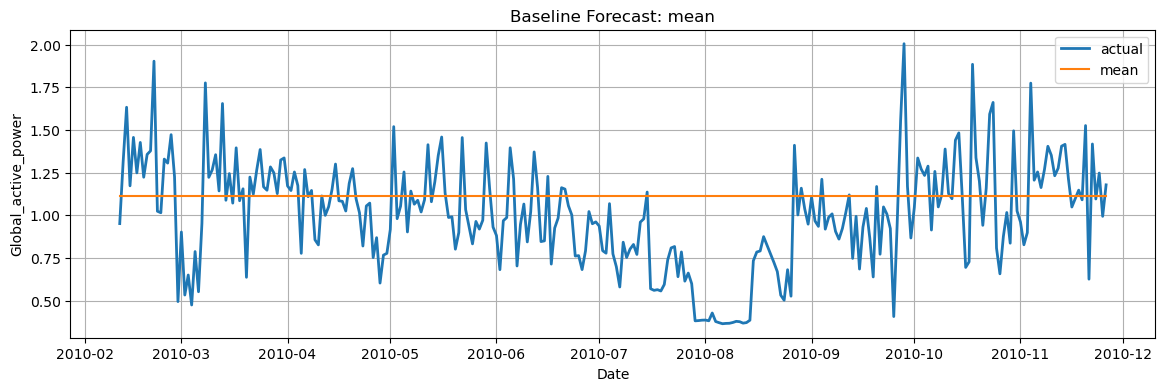

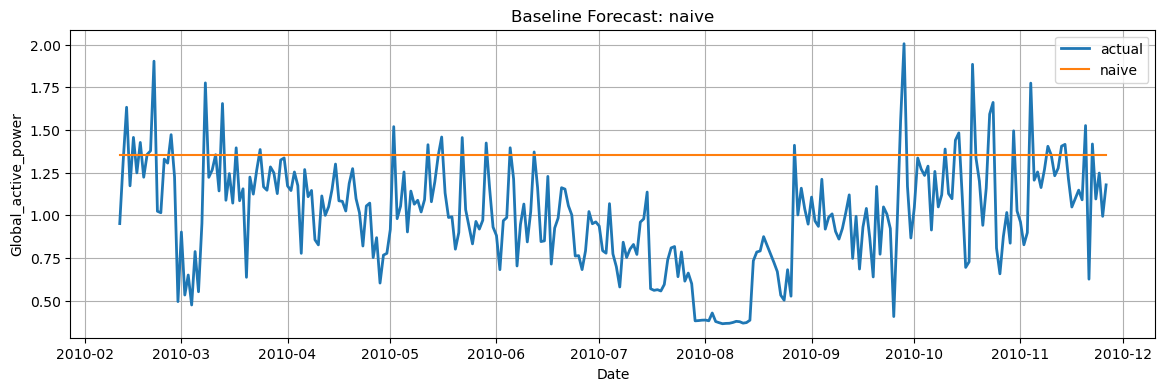

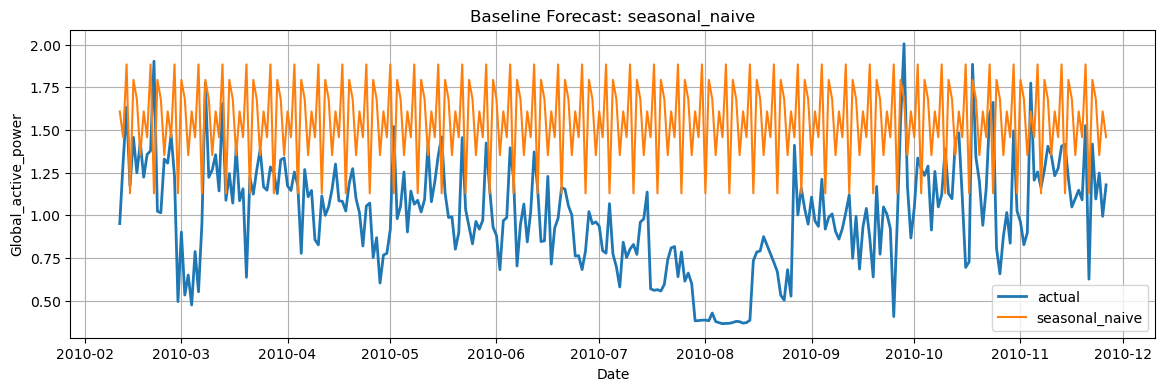

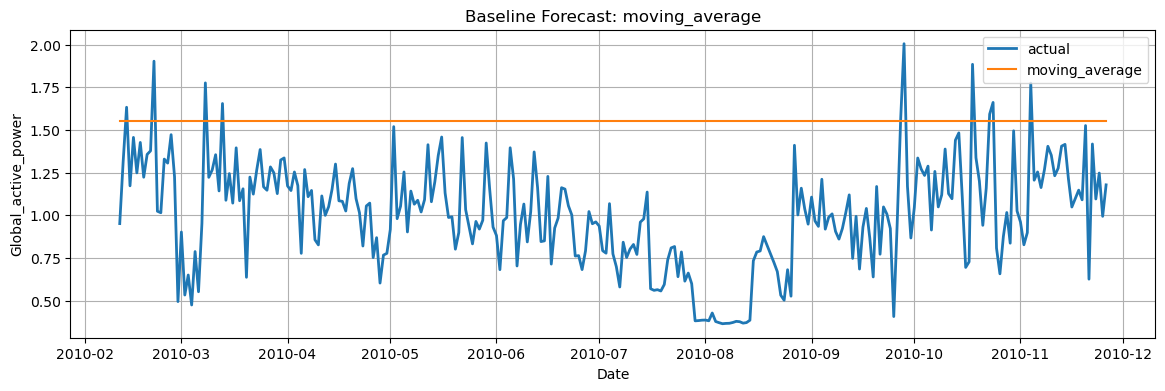

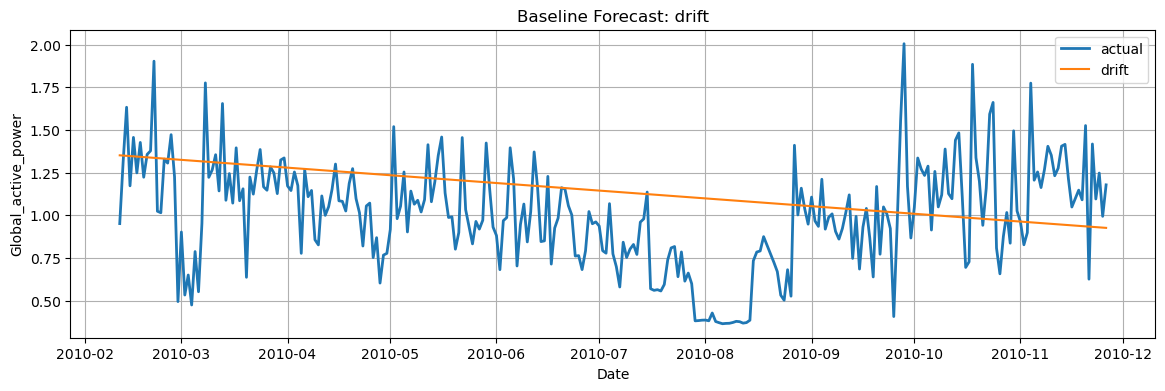

In [14]:
for model_name in baseline_models.keys():
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_test.index, y_test, label="actual", linewidth=2)
    ax.plot(y_test.index, baseline_pred_df[model_name], label=model_name)
    ax.set_title(f"Baseline Forecast: {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Global_active_power")
    ax.grid(True)
    ax.legend()
    plt.show()


## 4. ベースモデルを一つの図にまとめて表示

複数のベースラインを一つの図に重ねることで、各モデルの予測傾向を比較する。


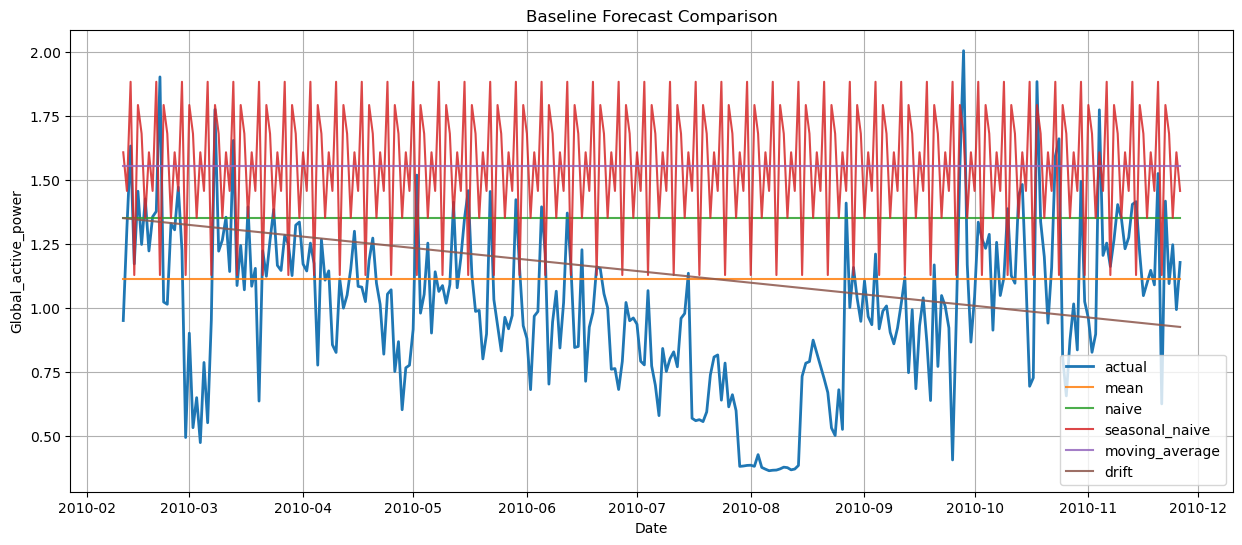

In [15]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test, label="actual", linewidth=2)

for model_name in baseline_models.keys():
    ax.plot(
        y_test.index,
        baseline_pred_df[model_name],
        label=model_name,
        alpha=0.85,
    )

ax.set_title("Baseline Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.grid(True)
ax.legend()
plt.show()


### ベースラインモデルの考察

ベースラインモデルは、複雑なモデルを評価するための最低基準である。  
平均値予測は系列全体の代表値を用いるため、変動をほとんど表現できない。  
Naive予測は直近水準が続くという仮定に基づくため、短期的な水準の持続性がある場合には有効である。  
季節Naive予測は周期性が強い場合に有効であり、家庭電力データのように曜日効果がある系列では重要な比較対象になる。  
移動平均予測は短期的なスパイクをならしつつ直近水準を反映するため、日次平均系列では安定した基準になりやすい。  
ドリフト予測は長期的な線形トレンドを仮定するため、明確な一方向のトレンドが弱い系列では過剰に外挿する可能性がある。


## 5. 単変量時系列モデルの実装

次に、目的変数 `Global_active_power` の過去の値のみを用いる単変量時系列モデルを実装する。

ここでは以下の3つを扱う。

1. 単純指数平滑化
2. Holt法
3. Holt-Winter法

指数平滑化系のモデルは、過去の観測値に指数的に減衰する重みを与えて将来を予測する。  
Holt法ではトレンド成分を追加し、Holt-Winter法ではトレンド成分と季節成分を追加できる。


### 単純指数平滑化


In [16]:
ses_model = SimpleExpSmoothing(
    y_train,
    initialization_method="estimated",
).fit(optimized=True)

ses_pred = ses_model.forecast(len(y_test))
ses_pred = pd.Series(ses_pred, index=y_test.index, name="simple_exponential_smoothing")


### Holt法


In [17]:
holt_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal=None,
    initialization_method="estimated",
).fit(optimized=True)

holt_pred = holt_model.forecast(len(y_test))
holt_pred = pd.Series(holt_pred, index=y_test.index, name="holt")


### Holt-Winter法

日次データに対して、週周期の季節性を仮定して `seasonal_periods=7` とする。


In [18]:
holt_winters_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_period,
    initialization_method="estimated",
).fit(optimized=True)

holt_winters_pred = holt_winters_model.forecast(len(y_test))
holt_winters_pred = pd.Series(holt_winters_pred, index=y_test.index, name="holt_winters")


### 単変量時系列モデルの予測結果をDataFrameにまとめる


In [19]:
univariate_pred_df = pd.DataFrame({
    "actual": y_test,
    "simple_exponential_smoothing": ses_pred,
    "holt": holt_pred,
    "holt_winters": holt_winters_pred,
})
univariate_pred_df.index = y_test.index

display(univariate_pred_df.head())
display(univariate_pred_df.tail())


,actual,simple_exponential_smoothing,holt,holt_winters
datetime,,,,
2010-02-11,0.951228,1.550951,1.548848,1.500658
2010-02-12,1.314582,1.550951,1.548417,1.369233
2010-02-13,1.633025,1.550951,1.547986,1.695380
2010-02-14,1.172569,1.550951,1.547556,1.520407
2010-02-15,1.456342,1.550951,1.547125,1.400211


,actual,simple_exponential_smoothing,holt,holt_winters
datetime,,,,
2010-11-22,1.417733,1.550951,1.426557,1.283552
2010-11-23,1.095511,1.550951,1.426126,1.425881
2010-11-24,1.247394,1.550951,1.425696,1.524684
2010-11-25,0.993864,1.550951,1.425265,1.381083
2010-11-26,1.178230,1.550951,1.424835,1.249658


## 6. 単変量モデルの予測精度をまとめる

ベースラインモデルと同じ評価指標で、単変量時系列モデルを評価する。


In [20]:
univariate_models = {
    "simple_exponential_smoothing": ses_pred,
    "holt": holt_pred,
    "holt_winters": holt_winters_pred,
}

univariate_results = []
for model_name, pred in univariate_models.items():
    metrics = evaluate_forecast(
        y_true=y_test,
        y_pred=pred,
        y_train=y_train,
        mase_period=1,
    )
    univariate_results.append({"model": model_name, **metrics})

univariate_results_df = pd.DataFrame(univariate_results).sort_values("MAE").reset_index(drop=True)
display(univariate_results_df)


,model,MAE,MSE,RMSE,MASE
0,holt_winters,0.485024,0.318050,0.563959,1.682913
1,holt,0.503245,0.330322,0.574737,1.746137
2,simple_exponential_smoothing,0.561204,0.397112,0.630168,1.947242


### ベースラインモデルと単変量時系列モデルの比較


In [21]:
all_statistical_results_df = pd.concat(
    [
        baseline_results_df.assign(model_type="baseline"),
        univariate_results_df.assign(model_type="univariate"),
    ],
    axis=0,
    ignore_index=True,
)
all_statistical_results_df = all_statistical_results_df.sort_values("MAE").reset_index(drop=True)
display(all_statistical_results_df)


,model,MAE,MSE,RMSE,MASE,model_type
0,mean,0.257821,0.109131,0.330350,0.894577,baseline
1,drift,0.280145,0.123866,0.351947,0.972035,baseline
2,naive,0.389403,0.219258,0.468249,1.351133,baseline
3,holt_winters,0.485024,0.318050,0.563959,1.682913,univariate
4,holt,0.503245,0.330322,0.574737,1.746137,univariate
5,simple_exponential_smoothing,0.561204,0.397112,0.630168,1.947242,univariate
6,moving_average,0.565244,0.401876,0.633937,1.961260,baseline
7,seasonal_naive,0.583504,0.464794,0.681758,2.024615,baseline


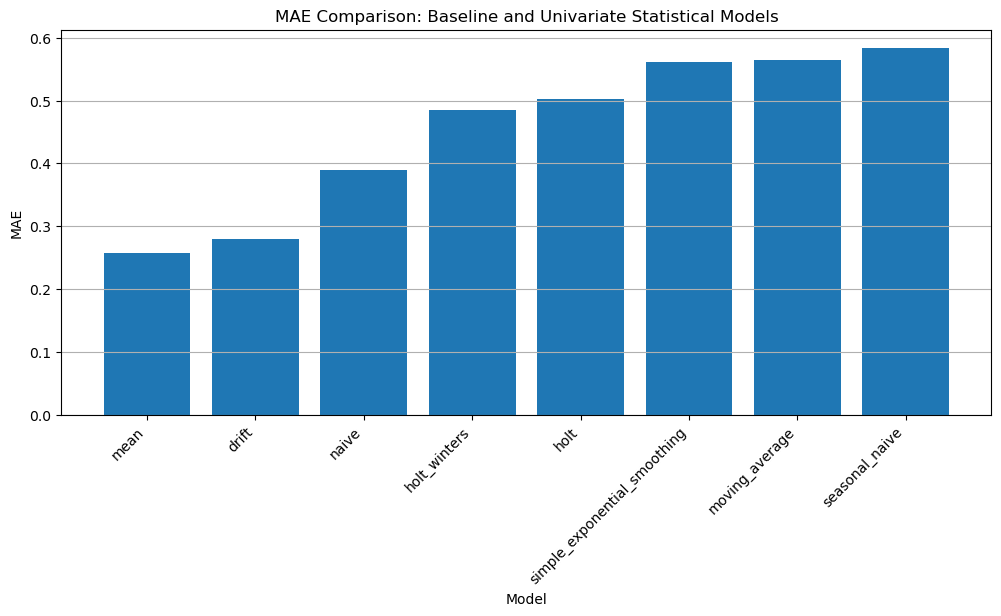

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = all_statistical_results_df.sort_values("MAE")
ax.bar(plot_df["model"], plot_df["MAE"])
ax.set_title("MAE Comparison: Baseline and Univariate Statistical Models")
ax.set_xlabel("Model")
ax.set_ylabel("MAE")
ax.grid(axis="y")
plt.xticks(rotation=45, ha="right")
plt.show()


## 7. 単変量時系列モデルの可視化

実測値と、単純指数平滑化・Holt法・Holt-Winter法の予測値を比較する。


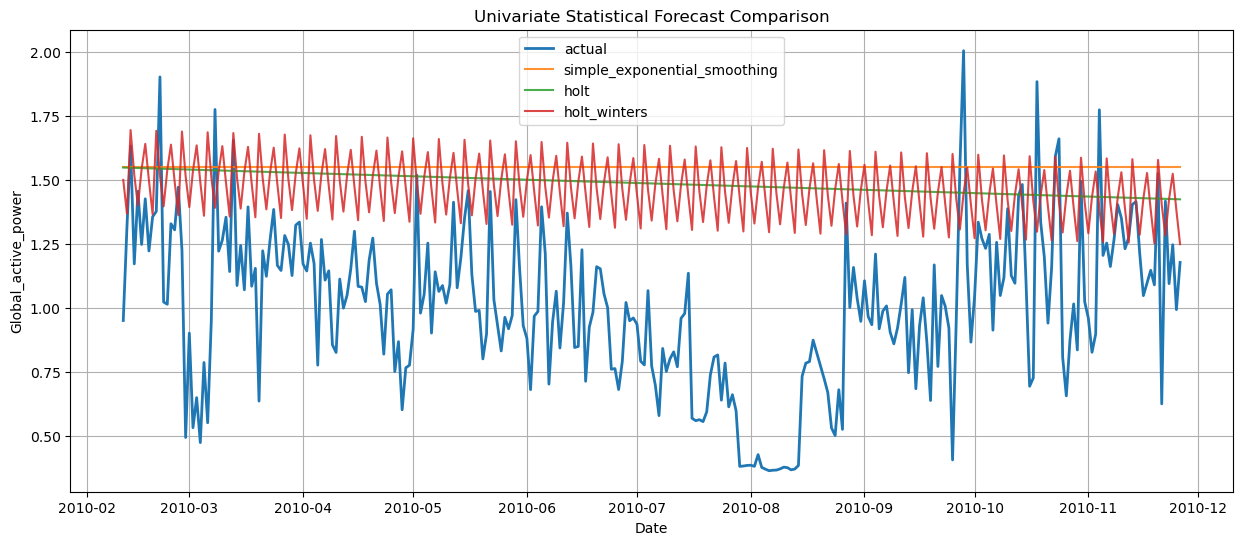

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test, label="actual", linewidth=2)

for model_name in univariate_models.keys():
    ax.plot(
        y_test.index,
        univariate_pred_df[model_name],
        label=model_name,
        alpha=0.85,
    )

ax.set_title("Univariate Statistical Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.grid(True)
ax.legend()
plt.show()


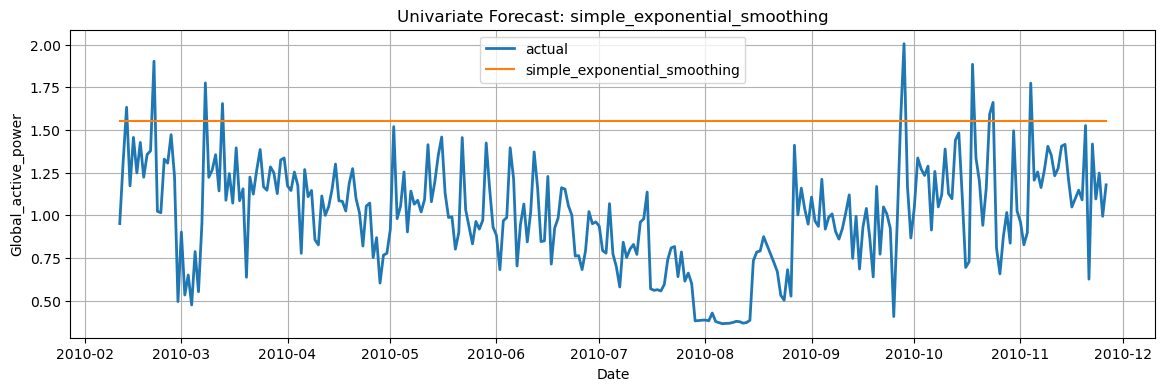

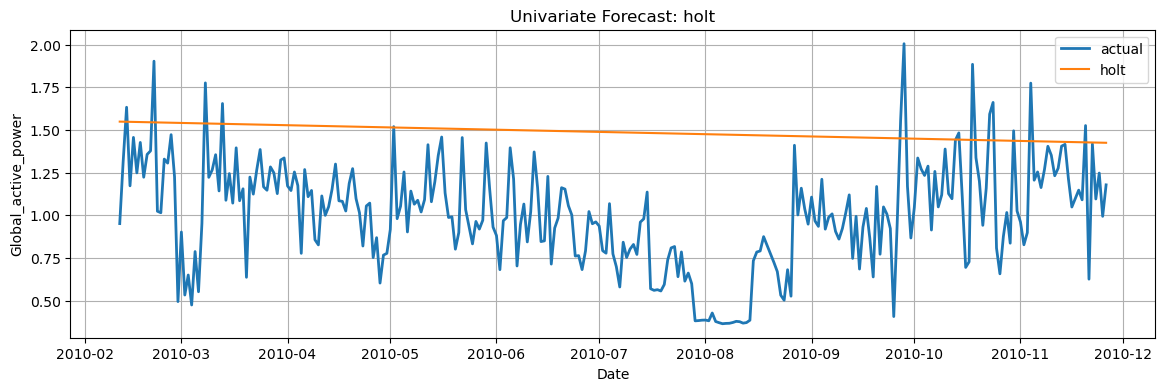

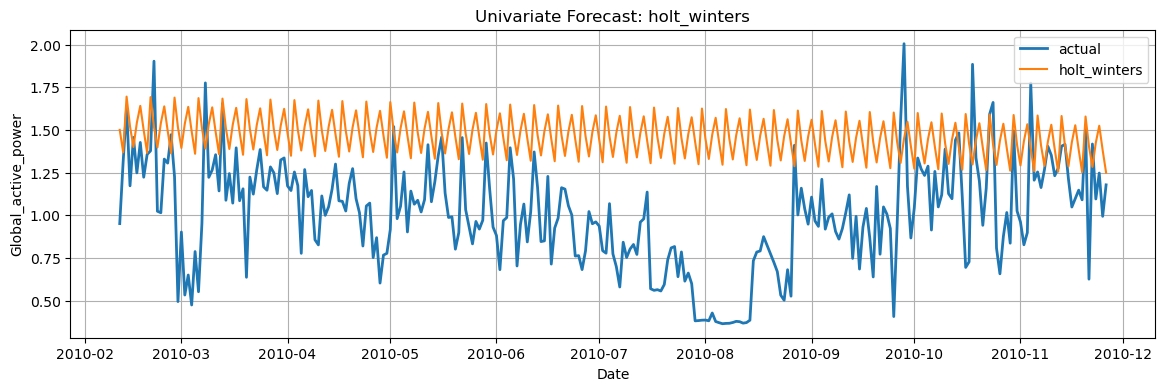

In [24]:
for model_name in univariate_models.keys():
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_test.index, y_test, label="actual", linewidth=2)
    ax.plot(y_test.index, univariate_pred_df[model_name], label=model_name)
    ax.set_title(f"Univariate Forecast: {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Global_active_power")
    ax.grid(True)
    ax.legend()
    plt.show()


### 単変量時系列モデルの考察

単純指数平滑化は、系列の水準を平滑化して予測するため、明確なトレンドや季節性を直接は表現しない。  
Holt法はトレンド成分を含むため、系列に一方向の変化がある場合には有効である。  
Holt-Winter法はさらに季節成分を含むため、週周期のような繰り返しパターンを取り込める。

一方で、家庭電力データは短時間のスパイクや生活リズムに由来する非線形な変動を含むため、単変量の指数平滑化系モデルだけでは十分に表現できない場合がある。  
このため、次の段階ではラグ特徴量・ローリング統計量・カレンダー特徴量を用いた機械学習モデルと比較することが重要である。


## まとめ

このノートブックでは、`Global_active_power` の日次平均系列に対して、ベースラインモデルと単変量時系列モデルを実装した。

得られた評価結果は、以後の機械学習モデル・深層学習モデル・TDA特徴量追加モデルの比較基準になる。  
特に、複雑なモデルを使う場合でも、少なくとも単純なベースラインや指数平滑化モデルを上回る必要がある。
